# KKBox Churn Prediction Kaggle Baseline

This baseline does the following: 
- Combine train and test users
- Add member and transaction aggregate features
- Train an XGBoost binary classifier, and write `submission_baseline.csv`.

In [14]:
# Run this cell once if xgboost is missing from the active kernel.
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


## Imports and Configuration

In [15]:
from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import xgboost as xgb
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)

RANDOM_STATE = 12345
BEST_ITER = 1512
TRANSACTIONS_CHUNKSIZE = 2_000_000

PROJECT_ROOT = Path("F:/KKBox's Churn Prediction Challenge")
DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_PATH = PROJECT_ROOT / "outputs" / "submissions" / "baseline" / "submission_baseline.csv"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_PATH: {OUTPUT_PATH}")

PROJECT_ROOT: F:\KKBox's Churn Prediction Challenge
DATA_DIR: F:\KKBox's Churn Prediction Challenge\data\raw
OUTPUT_PATH: F:\KKBox's Churn Prediction Challenge\outputs\submissions\baseline\submission_baseline.csv


## Load Train and Submission Users

- 测试数据的 `is_churn` 是 `NaN`
- 建立是否重复的简单特征 `is_duplicate`，重复用户可能携带额外信号，也是 Kaggle Baseline 里常见的泄露型特征

In [16]:
train = pd.read_csv(
    DATA_DIR / "train.csv",
    dtype={"msno": "string", "is_churn": "float32"},
)

sample_submission = pd.read_csv(
    PROJECT_ROOT / "outputs" / "submissions" / "sample_submission_v2.csv",
    dtype={"msno": "string"},
    usecols=["msno"],
)

test_template = sample_submission.copy()
test_template["is_churn"] = np.nan

# 合并训练和测试数据，统一处理
data = pd.concat([train, test_template], axis=0, ignore_index=True)

# 建立是否重复的简单特征，重复用户可能携带额外信号，也是 Kaggle Baseline 里常见的泄露型特征
data["is_duplicate"] = data["msno"].duplicated(keep=False).astype("int8")

print(f"train rows: {len(train):,}")
print(f"test rows: {len(sample_submission):,}")
print(f"combined rows: {len(data):,}")
display(data.head())

train rows: 992,931
test rows: 907,471
combined rows: 1,900,402


,msno,is_churn,is_duplicate
0,waLDQMmcOu2jLDaV1ddDkgCrB/jl6sD66Xzs0Vqax1Y=,1.0,0
1,QA7uiXy8vIbUSPOkCf9RwQ3FsT8jVq2OxDr8zqa7bRQ=,1.0,0
2,fGwBva6hikQmTJzrbz/2Ezjm5Cth5jZUNvXigKK2AFA=,1.0,0
3,mT5V8rEpa+8wuqi6x0DoVd3H5icMKkE9Prt49UlmK+4=,1.0,1
4,XaPhtGLk/5UvvOYHcONTwsnH97P4eGECeq+BARGItRw=,1.0,0


## Member Features

`members_v3.csv` provides profile fields and `registration_init_time`. This notebook maps gender using 

The `expiration-date` features are intentionally omitted because `members_v3.csv` does not contain `expiration_date`.

1. 映射 `gender`，female -> 1, male -> 2, missing/unknown -> 0
2. 解析 `registration_init_time`，拆出多个特征：
    - `reg_fulldate`：完整注册日期的数字形式
    - `reg_year`：注册年份
    - `reg_month`：注册月份
    - `reg_mday`：注册日
    - `reg_wday`：注册星期几（默认lubridate::wday格式，周日=1，周一=2，...，周六=7）
3. 删除原始日期列 (`registration_init_time`)

In [17]:
# 读取会员资料
member_dtypes = {
    "msno": "string",
    "city": "float32",
    "bd": "float32",
    "gender": "string",
    "registered_via": "float32",
    "registration_init_time": "string",
}

members = pd.read_csv(DATA_DIR / "members_v3.csv", dtype=member_dtypes)

# 处理 gender, female -> 1, male -> 2, missing/unknown -> 0
members["gender"] = (
    members["gender"]
    .map({"female": 1, "male": 2})
    .fillna(0)
    .astype("int8")
)

# 解析注册日期（20120315等转为真正的日期格式）
registration_date = pd.to_datetime(
    members["registration_init_time"],
    format="%Y%m%d",
    errors="coerce",
)

"""
从注册日期中拆出多个特征：
reg_fulldate：完整注册日期的数字形式
reg_year：注册年份
reg_month：注册月份
reg_mday：注册日
reg_wday：注册星期几（默认lubridate::wday格式，周日=1，周一=2，...，周六=7）
"""
members["reg_fulldate"] = pd.to_numeric(
    members["registration_init_time"],
    errors="coerce",
).astype("float32")
members["reg_year"] = registration_date.dt.year.astype("float32")
members["reg_month"] = registration_date.dt.month.astype("float32")
members["reg_mday"] = registration_date.dt.day.astype("float32")
members["reg_wday"] = ((registration_date.dt.dayofweek + 1) % 7 + 1).astype("float32")

# 删除原始的 registration_init_time 列
members = members.drop(columns=["registration_init_time"])

# 合并到训练/预测主表
data = data.merge(members, on="msno", how="left", sort=False)

# 清理内存
del members, registration_date
gc.collect()

print(f"rows after member merge: {len(data):,}")
display(data.head())

rows after member merge: 1,900,402


,msno,is_churn,is_duplicate,city,bd,gender,registered_via,reg_fulldate,reg_year,reg_month,reg_mday,reg_wday
0,waLDQMmcOu2jLDaV1ddDkgCrB/jl6sD66Xzs0Vqax1Y=,1.0,0,18.0,36.0,1.0,9.0,20050406.0,2005.0,4.0,6.0,4.0
1,QA7uiXy8vIbUSPOkCf9RwQ3FsT8jVq2OxDr8zqa7bRQ=,1.0,0,10.0,38.0,2.0,9.0,20050408.0,2005.0,4.0,7.0,5.0
2,fGwBva6hikQmTJzrbz/2Ezjm5Cth5jZUNvXigKK2AFA=,1.0,0,11.0,27.0,1.0,9.0,20051016.0,2005.0,10.0,16.0,1.0
3,mT5V8rEpa+8wuqi6x0DoVd3H5icMKkE9Prt49UlmK+4=,1.0,1,13.0,23.0,1.0,9.0,20051102.0,2005.0,11.0,2.0,4.0
4,XaPhtGLk/5UvvOYHcONTwsnH97P4eGECeq+BARGItRw=,1.0,0,3.0,27.0,2.0,9.0,20051228.0,2005.0,12.0,28.0,4.0


## Transaction Aggregates

按每个用户的 `msno` 构造了一组交易聚合特征：
1. `payment_method_id` 用户历史交易中使用的付款方式 ID 的平均值
2. `payment_plan_days` 用户平均每次购买的会员套餐天数
3. `plan_list_price` 用户平均每次交易的套餐标价
4. `actual_amount_paid` 用户平均每次交易的实际支付金额
5. `is_auto_renew` 用户交易中自动续订的比例
6. `is_cancel` 用户交易中取消订阅的比例
7. `payment_price_diff` 平均每次交易的标价与实际支付金额差值
8. `n_transactions` 用户历史交易次数



In [18]:
TRANSACTION_MEAN_COLUMNS = [
    "payment_method_id",
    "payment_plan_days",
    "plan_list_price",
    "actual_amount_paid",
    "is_auto_renew",
    "is_cancel",
    "payment_price_diff",
]

transaction_dtypes = {
    "msno": "object",
    "payment_method_id": "float32",
    "payment_plan_days": "float32",
    "plan_list_price": "float32",
    "actual_amount_paid": "float32",
    "is_auto_renew": "float32",
    "is_cancel": "float32",
}
transaction_usecols = [
    "msno",
    "payment_method_id",
    "payment_plan_days",
    "plan_list_price",
    "actual_amount_paid",
    "is_auto_renew",
    "is_cancel",
]

# 确定需要的用户
target_msnos = set(data["msno"].dropna().astype(str).unique())
transaction_parts = []
rows_seen = 0
rows_kept = 0

In [19]:
# 分块读取 transactions.csv
for chunk_no, chunk in enumerate(
    pd.read_csv(
        DATA_DIR / "transactions.csv",
        usecols=transaction_usecols,
        dtype=transaction_dtypes,
        chunksize=TRANSACTIONS_CHUNKSIZE,
    ),
    start=1,
):
    rows_seen += len(chunk)
    # 每个 chunk 里只保留目标用户的交易
    chunk = chunk[chunk["msno"].isin(target_msnos)]
    rows_kept += len(chunk)
    if chunk.empty:
        print(f"chunk {chunk_no}: no matching users")
        continue

    # 构造价格差特征，表示计划价格与实际支付的差额
    """
    plan_list_price = 149
    actual_amount_paid = 99
    payment_price_diff = 149 - 99 = 50
    可能反映折扣、优惠、实际支付差异等信息
    """
    chunk["payment_price_diff"] = chunk["plan_list_price"] - chunk["actual_amount_paid"]

    # 按用户聚合交易特征，计算每个用户的交易总和和交易次数
    """
    payment_method_id 总和
    payment_plan_days 总和
    plan_list_price 总和
    actual_amount_paid 总和
    is_auto_renew 总和
    is_cancel 总和
    payment_price_diff 总和
    n_transactions：交易次数
    """
    grouped = chunk.groupby("msno", observed=True).agg(
        payment_method_id=("payment_method_id", "sum"),
        payment_plan_days=("payment_plan_days", "sum"),
        plan_list_price=("plan_list_price", "sum"),
        actual_amount_paid=("actual_amount_paid", "sum"),
        is_auto_renew=("is_auto_renew", "sum"),
        is_cancel=("is_cancel", "sum"),
        payment_price_diff=("payment_price_diff", "sum"),
        n_transactions=("payment_method_id", "count"),
    )
    transaction_parts.append(grouped.astype("float32"))

    print(
        f"chunk {chunk_no}: seen={rows_seen:,}, kept={rows_kept:,}, "
        f"chunk_users={len(grouped):,}, parts={len(transaction_parts):,}"
    )

    del chunk, grouped
    gc.collect()

if not transaction_parts:
    raise ValueError("No matching transactions were found for train/test users.")

transaction_sums = (
    pd.concat(transaction_parts)
    .groupby(level=0, observed=True)
    .sum()
)

# 把部分字段的总和转为平均值
"""
平均 payment_method_id
平均套餐天数 payment_plan_days
平均标价 plan_list_price
平均实际支付金额 actual_amount_paid
自动续订比例 is_auto_renew
取消比例 is_cancel
平均价格差 payment_price_diff
交易次数 n_transactions
"""
transactions_agg = transaction_sums.copy()
transactions_agg[TRANSACTION_MEAN_COLUMNS] = transactions_agg[TRANSACTION_MEAN_COLUMNS].div(
    transactions_agg["n_transactions"], axis=0
)
transactions_agg = transactions_agg.reset_index()

for column in TRANSACTION_MEAN_COLUMNS + ["n_transactions"]:
    transactions_agg[column] = transactions_agg[column].astype("float32")

print(f"transaction rows seen: {rows_seen:,}")
print(f"transaction rows kept: {rows_kept:,}")
print(f"users with transaction features: {len(transactions_agg):,}")
display(transactions_agg.head())


del transaction_sums, transaction_parts, target_msnos
gc.collect()

chunk 1: seen=2,000,000, kept=1,511,901, chunk_users=731,292, parts=1
chunk 2: seen=4,000,000, kept=3,023,831, chunk_users=731,383, parts=2
chunk 3: seen=6,000,000, kept=4,535,291, chunk_users=731,011, parts=3
chunk 4: seen=8,000,000, kept=6,046,593, chunk_users=731,504, parts=4
chunk 5: seen=10,000,000, kept=7,558,290, chunk_users=731,247, parts=5
chunk 6: seen=12,000,000, kept=9,069,793, chunk_users=731,485, parts=6
chunk 7: seen=14,000,000, kept=10,581,455, chunk_users=731,473, parts=7
chunk 8: seen=16,000,000, kept=12,092,975, chunk_users=730,665, parts=8
chunk 9: seen=18,000,000, kept=13,604,883, chunk_users=731,175, parts=9
chunk 10: seen=20,000,000, kept=15,116,660, chunk_users=730,910, parts=10
chunk 11: seen=21,547,746, kept=16,286,670, chunk_users=650,166, parts=11
transaction rows seen: 21,547,746
transaction rows kept: 16,286,670
users with transaction features: 1,066,175


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,is_cancel,payment_price_diff,n_transactions
0,+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=,41.0,30.000000,99.000000,99.0,1.0,0.0,0.000000,4.0
1,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,39.0,28.578947,141.157898,149.0,1.0,0.0,-7.842105,19.0
2,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,41.0,28.846153,143.269226,149.0,1.0,0.0,-5.730769,26.0
3,++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=,41.0,30.000000,149.000000,149.0,1.0,0.0,0.000000,12.0
4,++/UDNo9DLrxT8QVGiDi1OnWfczAdEwThaVyD0fXO50=,39.0,28.578947,141.157898,149.0,1.0,0.0,-7.842105,19.0


0

In [20]:
transactions_agg.describe()

,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,is_cancel,payment_price_diff,n_transactions
count,1.066175e+06,1.066175e+06,1.066175e+06,1.066175e+06,1.066175e+06,1.066175e+06,1.066175e+06,1.066175e+06
mean,3.882913e+01,3.555181e+01,1.529311e+02,1.557188e+02,8.458435e-01,1.640058e-02,-2.787771e+00,1.527579e+01
std,3.617182e+00,3.904404e+01,1.668943e+02,1.672573e+02,3.424006e-01,4.403102e-02,1.616252e+01,8.570702e+00
min,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.788000e+03,1.000000e+00
25%,3.800000e+01,2.888889e+01,9.900000e+01,9.900000e+01,1.000000e+00,0.000000e+00,-4.961538e+00,8.000000e+00
50%,4.100000e+01,3.000000e+01,1.346956e+02,1.409231e+02,1.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01
75%,4.100000e+01,3.000000e+01,1.490000e+02,1.490000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.200000e+01
max,4.100000e+01,4.500000e+02,2.000000e+03,2.000000e+03,1.000000e+00,1.000000e+00,1.490000e+02,7.100000e+01


## Merge Features and Build Matrices

把前面做好的特征合并到主数据里，然后拆分训练集和测试集

In [21]:
# 合并交易特征到主表（保留 data 里的所有用户）
data = data.merge(transactions_agg, on="msno", how="left", sort=False)

# 释放内存
del transactions_agg
gc.collect()

# 区分训练集和测试集（训练集有 is_churn 标签，测试集没有）
train_mask = data["is_churn"].notna()
test_mask = data["is_churn"].isna()

# 确定特征列，排除标识符和目标列
feature_names = [column for column in data.columns if column not in {"msno", "is_churn"}]

# 构建特征矩阵和标签
features = data[feature_names].apply(pd.to_numeric, errors="coerce").astype("float32") # 把所有特征转为数值类型
y_train = data.loc[train_mask, "is_churn"].astype("float32").to_numpy() # 提取训练标签 y_train
test_ids = data.loc[test_mask, "msno"].copy() # 保存测试集用户 ID test_ids，后续用于生成 submission

# 做安全检查
if len(y_train) != len(train):
    raise AssertionError(f"Expected {len(train):,} training rows, got {len(y_train):,}.")
if len(test_ids) != len(sample_submission):
    raise AssertionError(
        f"Expected {len(sample_submission):,} test rows, got {len(test_ids):,}."
    )
if any(column in feature_names for column in ["msno", "is_churn"]):
    raise AssertionError("Feature matrix includes an identifier or target column.")

# 转成稀疏矩阵，节省内存
train_sparse = sparse.csr_matrix(features.loc[train_mask].to_numpy(dtype=np.float32))
test_sparse = sparse.csr_matrix(features.loc[test_mask].to_numpy(dtype=np.float32))

if train_sparse.shape[1] != len(feature_names):
    raise AssertionError("Feature name count does not match train matrix columns.")
if test_sparse.shape[1] != len(feature_names):
    raise AssertionError("Feature name count does not match test matrix columns.")

print(f"feature count: {len(feature_names):,}")
print(f"train matrix: {train_sparse.shape}")
print(f"test matrix: {test_sparse.shape}")
display(features.head())

feature count: 18
train matrix: (992931, 18)
test matrix: (907471, 18)


,is_duplicate,city,bd,gender,registered_via,reg_fulldate,reg_year,reg_month,reg_mday,reg_wday,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,is_cancel,payment_price_diff,n_transactions
0,0.0,18.0,36.0,1.0,9.0,20050406.0,2005.0,4.0,6.0,4.0,38.000000,18.500000,74.500000,74.500000,0.000000,0.000000,0.000000,2.0
1,0.0,10.0,38.0,2.0,9.0,20050408.0,2005.0,4.0,7.0,5.0,38.869564,28.826086,143.869568,150.347824,0.956522,0.086957,-6.478261,23.0
2,0.0,11.0,27.0,1.0,9.0,20051016.0,2005.0,10.0,16.0,1.0,38.400002,30.000000,149.199997,149.199997,0.800000,0.100000,0.000000,10.0
3,1.0,13.0,23.0,1.0,9.0,20051102.0,2005.0,11.0,2.0,4.0,27.500000,410.000000,894.000000,894.000000,0.000000,0.000000,0.000000,2.0
4,0.0,3.0,27.0,2.0,9.0,20051228.0,2005.0,12.0,28.0,4.0,38.000000,98.125000,447.000000,447.000000,0.000000,0.000000,0.000000,8.0


## Train XGBoost

In [22]:
# 把数据转换成 XGBoost 专用格式
dtrain = xgb.DMatrix(
    data=train_sparse,
    label=y_train,
    missing=np.nan,
    feature_names=feature_names,
)
dtest = xgb.DMatrix(
    data=test_sparse,
    missing=np.nan,
    feature_names=feature_names,
)

# 设置模型参数
xgb_params = {
    "booster": "gbtree",
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "eta": 0.02,
    "gamma": 1,
    "max_depth": 6,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": RANDOM_STATE,
}

# 交叉验证选择更合理的 BEST_ITER，避免过拟合
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
folds = list(cv.split(train_sparse, y_train))
xgb_cv = xgb.cv(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=1000,
    folds=folds,
    metrics="logloss",
    early_stopping_rounds=50,
    seed=RANDOM_STATE,
    verbose_eval=10,
)
BEST_ITER = len(xgb_cv)

# 训练模型
xgb_model = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=BEST_ITER,
    evals=[(dtrain, "train")],
    verbose_eval=100,
)

[0]	train-logloss:0.23009+0.00007	test-logloss:0.23009+0.00007
[10]	train-logloss:0.18563+0.00009	test-logloss:0.18574+0.00009
[20]	train-logloss:0.15812+0.00009	test-logloss:0.15830+0.00017
[30]	train-logloss:0.14137+0.00009	test-logloss:0.14162+0.00023
[40]	train-logloss:0.12859+0.00009	test-logloss:0.12890+0.00027
[50]	train-logloss:0.11915+0.00010	test-logloss:0.11950+0.00030
[60]	train-logloss:0.11210+0.00011	test-logloss:0.11250+0.00032
[70]	train-logloss:0.10667+0.00010	test-logloss:0.10711+0.00035
[80]	train-logloss:0.10268+0.00009	test-logloss:0.10316+0.00039
[90]	train-logloss:0.09941+0.00010	test-logloss:0.09993+0.00039
[100]	train-logloss:0.09653+0.00011	test-logloss:0.09710+0.00040
[110]	train-logloss:0.09433+0.00011	test-logloss:0.09493+0.00042
[120]	train-logloss:0.09250+0.00011	test-logloss:0.09314+0.00043
[130]	train-logloss:0.09127+0.00011	test-logloss:0.09195+0.00043
[140]	train-logloss:0.08994+0.00012	test-logloss:0.09066+0.00044
[150]	train-logloss:0.08891+0.00012	

## Feature Importance

确认：

- 哪些特征被模型使用了
- 哪些特征对预测贡献最大
- 哪些特征可能不太重要

,feature,gain
0,is_duplicate,3494.730469
1,is_auto_renew,384.239655
2,is_cancel,174.733765
3,n_transactions,76.566032
4,payment_method_id,58.358135
5,payment_price_diff,51.114708
6,plan_list_price,45.344696
7,city,39.417988
8,payment_plan_days,29.033539
9,actual_amount_paid,25.963650


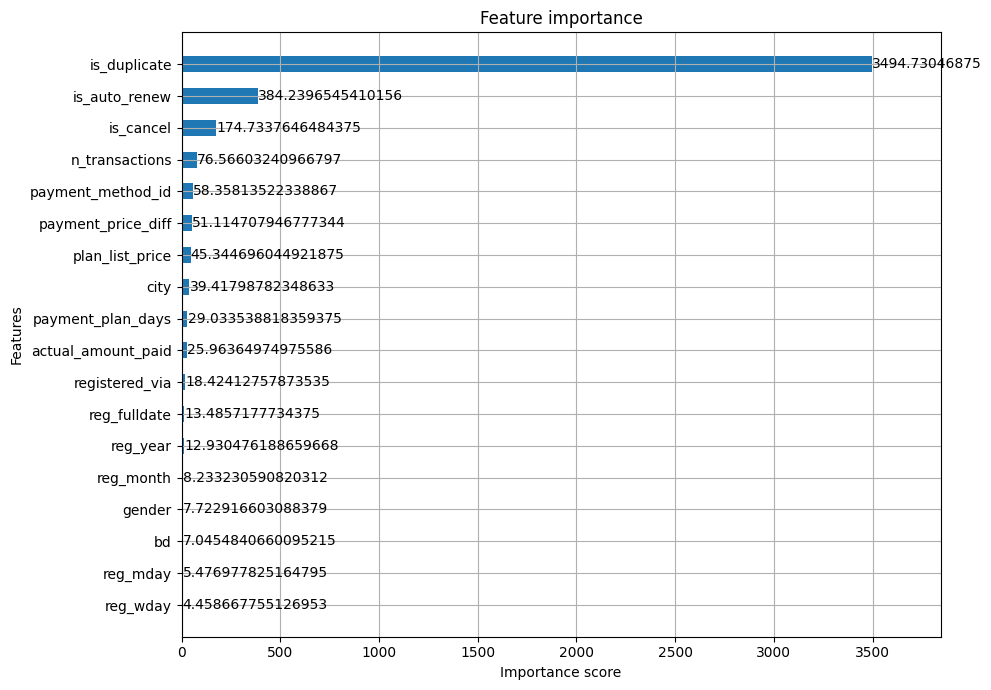

In [23]:
# 提取特征重要性
importance = xgb_model.get_score(importance_type="gain")

# 整理成表格并画图
importance_df = (
    pd.DataFrame(
        [{"feature": feature, "gain": gain} for feature, gain in importance.items()]
    )
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)

display(importance_df)

ax = xgb.plot_importance(
    xgb_model,
    max_num_features=min(25, len(feature_names)),
    importance_type="gain",
    height=0.5,
)
ax.figure.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

## Predict and Write Submission

The final CSV is written to the project root as `submission.csv`, with the same `msno` order as `sample_submission_v2.csv`.


In [24]:
# 预测 churn 概率
preds = pd.DataFrame(
    {
        "msno": test_ids.to_numpy(),
        "is_churn": xgb_model.predict(dtest),
    }
)
submission = sample_submission[["msno"]].merge(preds, on="msno", how="left", sort=False)

if len(submission) != len(sample_submission):
    raise AssertionError(
        f"Expected {len(sample_submission):,} submission rows, got {len(submission):,}."
    )
if submission["is_churn"].isna().any():
    missing_count = int(submission["is_churn"].isna().sum())
    raise ValueError(f"Submission contains {missing_count:,} missing predictions.")

submission.to_csv(OUTPUT_PATH, index=False)

print(f"wrote {len(submission):,} rows to {OUTPUT_PATH}")
display(submission.head())

wrote 907,471 rows to F:\KKBox's Churn Prediction Challenge\outputs\submissions\baseline\submission_baseline.csv


,msno,is_churn
0,4n+fXlyJvfQnTeKXTWT507Ll4JVYGrOC8LHCfwBmPE4=,0.000062
1,aNmbC1GvFUxQyQUidCVmfbQ0YeCuwkPzEdQ0RwWyeZM=,0.000127
2,rFC9eSG/tMuzpre6cwcMLZHEYM89xY02qcz7HL4//jc=,0.004911
3,WZ59dLyrQcE7ft06MZ5dj40BnlYQY7PHgg/54+HaCSE=,0.000048
4,aky/Iv8hMp1/V/yQHLtaVuEmmAxkB5GuasQZePJ7NU4=,0.000556
